In [24]:
%pip -q install ucimlrepo==0.0.7 pandas==2.2.3 wfdb==4.3.0

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import wfdb

SEED = 17
pd.set_option("display.max_columns", 30)

print(f"Ready for analysis | pandas {pd.__version__} | scikit-learn {sklearn.__version__}")


Note: you may need to restart the kernel to use updated packages.
Ready for analysis | pandas 2.2.3 | scikit-learn 1.9.0


### Load the dataset
Download the UCI heart disease data and display a small sample.

In [25]:
from ucimlrepo import fetch_ucirepo

heart_dataset = fetch_ucirepo(id=45)
features = heart_dataset.data.features.copy()
target_raw = heart_dataset.data.targets.copy()

print("UCI Heart Disease data loaded")
print(f"Features: {features.shape[0]} rows x {features.shape[1]} columns")
print(f"Outcome table: {target_raw.shape[0]} rows x {target_raw.shape[1]} columns")

display(features.head())
display(target_raw.head())


UCI Heart Disease data loaded
Features: 303 rows x 13 columns
Outcome table: 303 rows x 1 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


,num
0,0
1,2
2,1
3,0
4,0


### Inspect the data
Review the column names, data types, summary statistics, and overall shape.

In [26]:
print("Feature names:")
print(", ".join(features.columns))

print("\nColumn types:")
display(features.dtypes.rename("dtype").to_frame())

print("\nNumeric summary:")
display(features.describe().T.round(2))

print(f"\nRows and columns: {features.shape}")


Feature names:
age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal

Column types:


,dtype
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64



Numeric summary:


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.44,9.04,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.68,0.47,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.16,0.96,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.69,17.60,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.69,51.78,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.15,0.36,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.99,0.99,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.61,22.88,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.33,0.47,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.04,1.16,0.0,0.0,0.8,1.6,6.2



Rows and columns: (303, 13)


### Check missing values
Find which features contain missing measurements before modeling.

In [27]:
missing_report = features.isna().sum().sort_values(ascending=False)
missing_report = missing_report[missing_report.gt(0)]

if missing_report.empty:
    print("No missing feature values were found.")
else:
    print("Missing values by feature:")
    display(missing_report.to_frame("missing_count"))

print(f"Total missing entries: {int(features.isna().sum().sum())}")


Missing values by feature:


,missing_count
ca,4
thal,2


Total missing entries: 6


### Prepare the target
Convert the original outcome into two classes: no disease or disease.

In [28]:
target_column = target_raw.columns[0]

print("Original target column:", target_column)

print("\nOriginal target distribution:")
print(target_raw[target_column].value_counts().sort_index())

target_values = pd.to_numeric(
    target_raw[target_column],
    errors="coerce"
)

labels = (target_values > 0).astype(int)
labels.name = "heart_disease"

print("\nBinary target distribution:")
print(labels.value_counts())

print("\n0 = No Heart Disease")
print("1 = Heart Disease Present")


Original target column: num

Original target distribution:
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Binary target distribution:
heart_disease
0    164
1    139
Name: count, dtype: int64

0 = No Heart Disease
1 = Heart Disease Present


### View the class balance
Count the patients in each target class and plot the result.

heart_disease
0    164
1    139
Name: count, dtype: int64


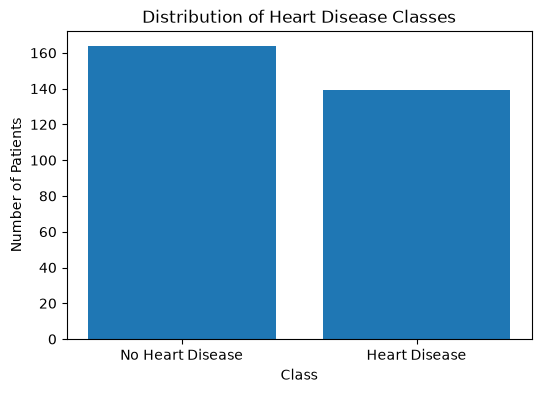

In [29]:
label_counts = labels.value_counts().sort_index()

print(label_counts)

plt.figure(figsize=(6, 4))
plt.bar(
    ["No Heart Disease", "Heart Disease"],
    [label_counts.get(0, 0), label_counts.get(1, 0)]
)

plt.xlabel("Class")
plt.ylabel("Number of Patients")
plt.title("Distribution of Heart Disease Classes")
plt.show()


### Examine feature relationships
Convert usable measurements to numeric form and calculate their correlations with the target.

In [30]:
numeric_data = features.apply(pd.to_numeric, errors="coerce")

correlation_frame = numeric_data.copy()
correlation_frame["heart_disease"] = labels.values

correlations = correlation_frame.corr()

print("Correlation Matrix:")
display(correlations.round(2))


Correlation Matrix:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,heart_disease
age,1.00,-0.10,0.10,0.28,0.21,0.12,0.15,-0.39,0.09,0.20,0.16,0.36,0.13,0.22
sex,-0.10,1.00,0.01,-0.06,-0.20,0.05,0.02,-0.05,0.15,0.10,0.04,0.09,0.38,0.28
cp,0.10,0.01,1.00,-0.04,0.07,-0.04,0.07,-0.33,0.38,0.20,0.15,0.23,0.27,0.41
trestbps,0.28,-0.06,-0.04,1.00,0.13,0.18,0.15,-0.05,0.06,0.19,0.12,0.10,0.13,0.15
chol,0.21,-0.20,0.07,0.13,1.00,0.01,0.17,-0.00,0.06,0.05,-0.00,0.12,0.01,0.09
fbs,0.12,0.05,-0.04,0.18,0.01,1.00,0.07,-0.01,0.03,0.01,0.06,0.15,0.07,0.03
restecg,0.15,0.02,0.07,0.15,0.17,0.07,1.00,-0.08,0.08,0.11,0.13,0.13,0.02,0.17
thalach,-0.39,-0.05,-0.33,-0.05,-0.00,-0.01,-0.08,1.00,-0.38,-0.34,-0.39,-0.26,-0.28,-0.42
exang,0.09,0.15,0.38,0.06,0.06,0.03,0.08,-0.38,1.00,0.29,0.26,0.15,0.33,0.43
oldpeak,0.20,0.10,0.20,0.19,0.05,0.01,0.11,-0.34,0.29,1.00,0.58,0.30,0.34,0.42


### Plot the correlation matrix
Display the calculated correlations as a heatmap.

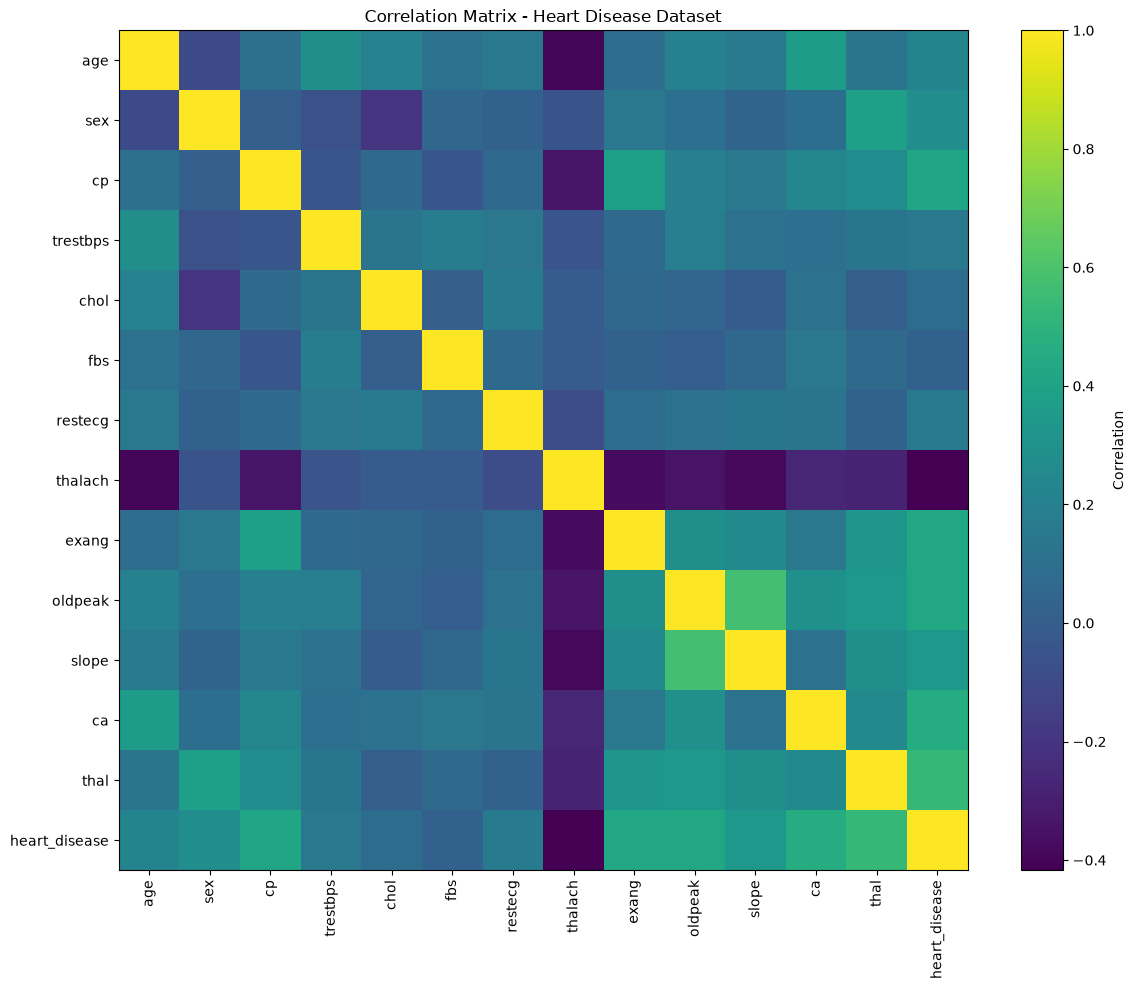

In [31]:
plt.figure(figsize=(12, 10))

plt.imshow(
    correlations,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlations.columns)),
    correlations.columns,
    rotation=90
)

plt.yticks(
    range(len(correlations.columns)),
    correlations.columns
)

plt.title("Correlation Matrix - Heart Disease Dataset")
plt.tight_layout()
plt.show()


### Rank target correlations
Show the features with the strongest positive and negative relationships with heart disease.

In [32]:
print(
    correlations["heart_disease"]
    .sort_values(ascending=False)
)


heart_disease    1.000000
thal             0.525689
ca               0.460442
exang            0.431894
oldpeak          0.424510
cp               0.414446
slope            0.339213
sex              0.276816
age              0.223120
restecg          0.169202
trestbps         0.150825
chol             0.085164
fbs              0.025264
thalach         -0.417167
Name: heart_disease, dtype: float64


### Separate feature types
Create lists for numeric and categorical columns used by preprocessing.

In [33]:
numeric_columns = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

category_columns = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

numeric_columns = [
    column for column in numeric_columns
    if column in features.columns
]

category_columns = [
    column for column in category_columns
    if column in features.columns
]

print("Numerical Features:")
print(numeric_columns)

print("\nCategorical Features:")
print(category_columns)


Numerical Features:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

Categorical Features:
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


### Split the data
Reserve 20 percent of the observations for testing and keep the class ratio balanced.

In [34]:
from sklearn.model_selection import train_test_split

train_features, test_features, train_labels, test_labels = train_test_split(
    features,
    labels,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

print("Training samples:", train_features.shape[0])
print("Testing samples:", test_features.shape[0])

print("\nTraining shape:", train_features.shape)
print("Testing shape:", test_features.shape)


Training samples: 242
Testing samples: 61

Training shape: (242, 13)
Testing shape: (61, 13)


### Build preprocessing steps
Fill missing values, scale numeric columns, and one-hot encode categorical columns.

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_steps = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

category_steps = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preparation = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_steps,
            numeric_columns
        ),
        (
            "category",
            category_steps,
            category_columns
        )
    ]
)

print("Preprocessing pipeline created.")


Preprocessing pipeline created.


### Train the classifier
Combine preprocessing with logistic regression and fit the complete pipeline.

In [36]:
from sklearn.linear_model import LogisticRegression

classifier = Pipeline(
    steps=[
        ("preprocessing", preparation),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

classifier.fit(train_features, train_labels)

print("Logistic Regression model trained successfully.")


Logistic Regression model trained successfully.


### Generate predictions
Use the fitted model to predict classes and disease probabilities for the test set.

In [37]:
predictions = classifier.predict(test_features)
probabilities = classifier.predict_proba(test_features)[:, 1]

print("First 10 predicted classes:")
print(predictions[:10])
print(predictions)

print("\nFirst 10 predicted probabilities:")
print(probabilities[:10])
print(probabilities)


First 10 predicted classes:
[0 1 0 0 0 0 0 0 1 0]
[0 1 0 0 0 0 0 0 1 0 1 0 0 1 1 1 1 1 1 1 1 0 1 0 1 0 0 1 0 1 0 1 1 1 0 1 0
 0 0 1 1 1 1 1 0 0 1 0 1 0 0 1 0 0 0 1 1 1 0 0 1]

First 10 predicted probabilities:
[0.20929567 0.60145782 0.02148916 0.03334708 0.3118407  0.01557081
 0.11681799 0.34861394 0.72209751 0.34742282]
[0.20929567 0.60145782 0.02148916 0.03334708 0.3118407  0.01557081
 0.11681799 0.34861394 0.72209751 0.34742282 0.96562059 0.02352735
 0.03427722 0.92799701 0.96827571 0.97890539 0.76590796 0.69300695
 0.70923836 0.97914056 0.72760374 0.04208378 0.84520128 0.23347798
 0.8115307  0.03938699 0.0903792  0.84562802 0.08436408 0.970595
 0.34885686 0.94051621 0.50786951 0.53170869 0.14601116 0.90067712
 0.19418282 0.26673102 0.03898709 0.8588818  0.85699284 0.98976197
 0.9817895  0.9468737  0.13415838 0.02757432 0.93762067 0.02694372
 0.98872108 0.09762274 0.0236043  0.98872836 0.48730039 0.05659382
 0.43752918 0.96712624 0.90997278 0.69666797 0.01324408 0.03647952
 0.967955

### Evaluate performance
Measure accuracy, ROC-AUC, and the classification report on held-out data.

In [38]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report
)

accuracy_value = accuracy_score(test_labels, predictions)
auc_value = roc_auc_score(test_labels, probabilities)

print("Accuracy:")
print(round(accuracy_value, 4))

print("\nROC-AUC:")
print(round(auc_value, 4))

print("\nClassification Report:")
print(
    classification_report(
        test_labels,
        predictions,
        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ]
    )
)


Accuracy:
0.8852

ROC-AUC:
0.9665

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.93      0.85      0.89        33
   Heart Disease       0.84      0.93      0.88        28

        accuracy                           0.89        61
       macro avg       0.89      0.89      0.89        61
    weighted avg       0.89      0.89      0.89        61



### Inspect the confusion matrix
Visualize correct and incorrect predictions for both classes.

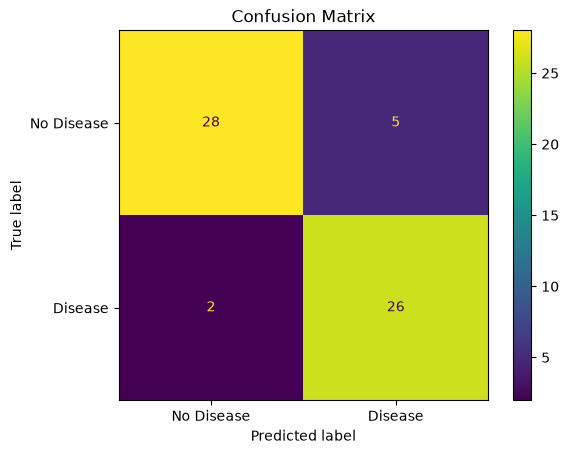

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    test_labels,
    predictions,
    display_labels=[
        "No Disease",
        "Disease"
    ]
)

plt.title("Confusion Matrix")
plt.show()


### Plot the ROC curve
Show how the model separates the two outcome classes across thresholds.

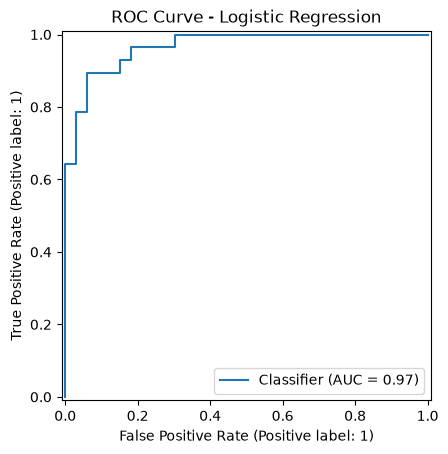

In [40]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    test_labels,
    probabilities
)

plt.title("ROC Curve - Logistic Regression")
plt.show()
